# PART9_Validate_breeding_plan
validate breeding plan using F2 progeny of N01-162 & N08-011, N17-071 & N08-011

In [2]:
import random
import copy
import ast
import math
import numpy as np
import pandas as pd
import pickle
from tqdm import tqdm
from glob import glob

from sklearn.linear_model import ElasticNet
from modules.training_module import train_Enet
from modules.make_data_for_prediction import make_data
from modules.breeding import make_regional_info, get_top_regions, plot_regional_info, plot_regional_info_with_target, target_effect_summary, visualize_line_genotype, visualize_RIL_genotype, visualize_F3_genotype
from modules.simulation import get_input_for_recombination, get_recombination_points, convert_genotype_to_pair, cross, check_target_regions, check_approximate_Hitomebore_ratio

In [16]:
F3_N01N08_genotype = pd.read_csv("../data/PARTEx_F3_genotype/vcf/F3_N01N08_SNP_with_parents_genotype.txt", sep="\t")
F3_N01N08_genotype.loc[(F3_N01N08_genotype.N01_KASALATH == 0) & (F3_N01N08_genotype.N08_BADARI_DHAN == 0), "N00_HITOMEBORE":] = 0
F3_N17N08_genotype = pd.read_csv("../data/PARTEx_F3_genotype/vcf/F3_N17N08_SNP_with_parents_genotype.txt", sep="\t")
F3_N17N08_genotype.loc[(F3_N17N08_genotype.N17_TAKANARI == 0) & (F3_N17N08_genotype.N08_BADARI_DHAN == 0), "N00_HITOMEBORE":] = 0
F3_genotype = pd.concat([F3_N01N08_genotype, F3_N17N08_genotype.iloc[:, 6:]], axis=1).iloc[:, 1:]
F3_genotype

,chr,pos,N00_HITOMEBORE,N01_162_S85.sort.bam,N01_KASALATH,N08_011_S86.sort.bam,N08_BADARI_DHAN,GP_B_01_S50.sort.bam,GP_B_02_S51.sort.bam,GP_B_03_S52.sort.bam,...,GP_A_34_S40.sort.bam,GP_A_35_S41.sort.bam,GP_A_46_S42.sort.bam,GP_A_48_S43.sort.bam,GP_A_49_S44.sort.bam,GP_A_53_S45.sort.bam,GP_A_54_S46.sort.bam,GP_A_55_S47.sort.bam,GP_A_56_S48.sort.bam,GP_A_57_S49.sort.bam
0,chr01,173888,0,2.0,2.0,0.0,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,chr01,173890,0,2.0,2.0,0.0,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,chr01,173911,0,2.0,2.0,0.0,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,chr01,173923,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,0.0,2.0,1.0,2.0,1.0,2.0,0.0,0.0
4,chr01,173989,0,2.0,2.0,0.0,2.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825387,chr12,27530133,0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0
825388,chr12,27530457,0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
825389,chr12,27530477,0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
825390,chr12,27530489,0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


## check target_region genotype ratio
### N01 & N08

In [ ]:
region2 = pd.read_csv("../data/PARTEx_F3_genotype/N01_162_region_1.csv")
region3 = pd.read_csv("../data/PARTEx_F3_genotype/N01_162_region_2.csv")
region1 = pd.read_csv("../data/PARTEx_F3_genotype/N01_162_region_3.csv")
region4 = pd.read_csv("../data/PARTEx_F3_genotype/N08_011_region_1.csv")
region5 = pd.read_csv("../data/PARTEx_F3_genotype/N08_011_region_2.csv")

target_regions = [['chr07', 25000000, 29000000],
                 ['chr01', 2000000, 6000000],
                 ['chr06', 25000000, 29000000],
                 ['chr04', 28000000, 32000000],
                 ['chr12', 23000000, 27000000]]

target_genotype_N01N08 = pd.DataFrame()
for i, region in enumerate([region1, region2, region3, region4, region5]):
    target_genotype = F3_genotype[(F3_genotype.chr == target_regions[i][0]) & (F3_genotype.pos.isin(region.pos.values)) & (F3_genotype.pos >= target_regions[i][1]) & (F3_genotype.pos <= target_regions[i][2])].loc[:, (F3_genotype.columns.str[:4] == "GP_B")|(F3_genotype.columns.str[:4] == "N01_")|(F3_genotype.columns.str[:4] == "N08_")]
    ratios = []
    for j in target_genotype.columns.values:
        each_target_genotype = target_genotype.loc[:, j].dropna()
#         print(j, each_target_genotype.shape[0])
        ratios.append(each_target_genotype.sum()/(each_target_genotype.shape[0]*2))
    target_genotype_N01N08[f"region{i+1}"] = ratios
target_genotype_N01N08.index = target_genotype.columns.values
line_order = ["GP_B_11_S60.sort.bam","GP_B_09_S58.sort.bam","GP_B_14_S63.sort.bam","GP_B_32_S81.sort.bam","GP_B_10_S59.sort.bam","GP_B_02_S51.sort.bam","GP_B_21_S70.sort.bam","GP_B_18_S67.sort.bam","GP_B_27_S76.sort.bam","GP_B_24_S73.sort.bam","GP_B_03_S52.sort.bam","GP_B_25_S74.sort.bam","GP_B_17_S66.sort.bam","GP_B_35_S84.sort.bam","GP_B_08_S57.sort.bam","GP_B_15_S64.sort.bam","N01_KASALATH","GP_B_30_S79.sort.bam","N01_162_S85.sort.bam","GP_B_19_S68.sort.bam","GP_B_01_S50.sort.bam","GP_B_31_S80.sort.bam","GP_B_12_S61.sort.bam","GP_B_05_S54.sort.bam","GP_B_29_S78.sort.bam","GP_B_22_S71.sort.bam","GP_B_16_S65.sort.bam","N08_BADARI_DHAN","N08_011_S86.sort.bam","GP_B_33_S82.sort.bam","GP_B_04_S53.sort.bam","GP_B_07_S56.sort.bam","GP_B_20_S69.sort.bam","GP_B_06_S55.sort.bam","GP_B_34_S83.sort.bam","GP_B_28_S77.sort.bam","GP_B_13_S62.sort.bam","GP_B_23_S72.sort.bam","GP_B_26_S75.sort.bam"]
target_genotype_N01N08.loc[line_order, :].to_csv("../data/PARTEx_F3_genotype/N01N08_F3_region_rate.csv")

### N17 & N08

In [33]:
region1 = pd.read_csv("../data/PARTEx_F3_genotype/N17_071_region_1.csv")
region3 = pd.read_csv("../data/PARTEx_F3_genotype/N17_071_region_2.csv")
region2 = pd.read_csv("../data/PARTEx_F3_genotype/N17_071_region_3.csv")
region4 = pd.read_csv("../data/PARTEx_F3_genotype/N08_011_region_1.csv")
region5 = pd.read_csv("../data/PARTEx_F3_genotype/N08_011_region_2.csv")

target_regions = [['chr01', 3000000, 7000000],
                ['chr06', 11000000, 15000000],
                ['chr06', 26000000, 30000000],
                ['chr04', 28000000, 32000000],
                ['chr12', 23000000, 27000000]]

target_genotype_N17N08 = pd.DataFrame()
for i, region in enumerate([region1, region2, region3, region4, region5]):
    target_genotype = F3_genotype[(F3_genotype.chr == target_regions[i][0]) & (F3_genotype.pos.isin(region.pos.values)) & (F3_genotype.pos >= target_regions[i][1]) & (F3_genotype.pos <= target_regions[i][2])].loc[:, (F3_genotype.columns.str[:4] == "GP_A")|(F3_genotype.columns.str[:4] == "N17_")|(F3_genotype.columns.str[:4] == "N08_")]
    ratios = []
    for j in target_genotype.columns.values:
        each_target_genotype = target_genotype.loc[:, j].dropna()
        ratios.append(each_target_genotype.sum()/(each_target_genotype.shape[0]*2))
    target_genotype_N17N08[f"region{i+1}"] = ratios
target_genotype_N17N08.index = target_genotype.columns.values
line_order = ["GP_A_08_S29.sort.bam","GP_A_29_S37.sort.bam","GP_A_28_S36.sort.bam","GP_A_32_S38.sort.bam","GP_A_13_S32.sort.bam","GP_A_48_S43.sort.bam","GP_A_33_S39.sort.bam","GP_A_19_S34.sort.bam","GP_A_16_S33.sort.bam","GP_A_34_S40.sort.bam","GP_A_55_S47.sort.bam","GP_A_46_S42.sort.bam","GP_A_53_S45.sort.bam","GP_A_49_S44.sort.bam","GP_A_35_S41.sort.bam","GP_A_02_S24.sort.bam","GP_A_09_S30.sort.bam","GP_A_01_S23.sort.bam","N17_TAKANARI","GP_A_24_S35.sort.bam","GP_A_06_S28.sort.bam","GP_A_03_S25.sort.bam","GP_A_05_S27.sort.bam","GP_A_56_S48.sort.bam","GP_A_04_S26.sort.bam","N08_BADARI_DHAN","N17_071_S87.sort.bam","N08_011_S86.sort.bam","GP_A_10_S31.sort.bam","GP_A_54_S46.sort.bam","GP_A_57_S49.sort.bam"]
target_genotype_N17N08.loc[line_order, :].to_csv("../data/PARTEx_F3_genotype/N17N08_F3_region_rate.csv")

## make HBs for visualization & prediction

In [45]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()

SNP_types = []
for chr_num in tqdm(range(1, 13)):
    chromosome = "chr{}".format(str(chr_num).zfill(2))
    F3_chr = F3_genotype[F3_genotype.chr == chromosome]
    # read original data
    parental = pd.read_csv("../data/genotype_data/NAM_all_imputed_all_filtered_commpos_ALL_genotype_{}.txt.gz".format(chromosome), usecols=range(25), sep="\t")
    parental = parental.loc[parental.pos.isin(F3_chr.pos), :]
    # extract paretal lines
    parental = parental.iloc[:, 2:23]
    # select family lines
    parental = parental.loc[:, family]
    SNP_type = ["".join(i) for i in parental.values.astype("str")]
    SNP_types.extend(SNP_type)
F3_genotype["SNP_type"] = SNP_types

100%|██████████| 12/12 [01:36<00:00,  8.02s/it]


In [49]:
imp_data = pd.read_csv("../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits_add.csv", dtype={'N01':str,'N03':str,'N04':str,'N05':str,'N06':str,'N07':str,'N08':str,'N09':str,'N10':str,'N11':str,'N12':str,'N13':str,'N14':str,'N16':str,'N17':str,'N18':str,'N19':str,'N20':str,'N21':str,'N22':str})
imp_data[(imp_data["N08"] == "2") | (imp_data["N17"] == "2")]

,chr,pos,SNP_type,GN_imps,PN_imps,GS_imps,sum_zscore,N01,N03,N04,...,N14,N16,N17,N18,N19,N20,N21,N22,start,end
0,chr01,214775_214775,20222222002200020000,-0.056993,0.008121,-0.025010,-1.505269,2,0,2,...,0,0,0,2,0,0,0,0,214775,214775
1,chr01,225668_225668,22222222002020220000,-0.204107,0.016932,-0.002993,-0.199950,2,2,2,...,2,0,2,2,0,0,0,0,225668,225668
2,chr01,539985,00222002000000200000,-0.533193,0.037530,-0.002205,-0.420309,0,0,2,...,0,0,2,0,0,0,0,0,539985,539985
3,chr01,546109_546811,00222202000220200000,-0.388413,0.025842,-0.012702,-1.093981,0,0,2,...,2,0,2,0,0,0,0,0,546109,546811
4,chr01,606022_653581,20000222000000200000,-0.447988,0.015759,0.005516,-0.503798,2,0,0,...,0,0,2,0,0,0,0,0,606022,653581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2290,chr12,27021476_27036870,22222222000022220200,-0.266526,0.042257,-0.001513,0.705293,2,2,2,...,2,2,2,2,0,2,0,0,27021476,27036870
2291,chr12,27101125_27262581,20222222000000220000,-0.249156,0.016866,-0.001454,-0.252156,2,0,2,...,0,0,2,2,0,0,0,0,27101125,27262581
2292,chr12,27299286_27511322,20222222000000020000,-0.438961,0.001273,0.005865,-1.032348,2,0,2,...,0,0,0,2,0,0,0,0,27299286,27511322
2294,chr12,27345724,22222222222222020222,-0.512102,0.001592,-0.003358,-1.868222,2,2,2,...,2,2,0,2,0,2,2,2,27345724,27345724


In [7]:
Haplotype_block = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")
haplotype_blocks = []
for SNP_type in tqdm(F3_genotype.SNP_type.unique()):
    F3_SNP_type = F3_genotype[F3_genotype["SNP_type"] == SNP_type]
    HB_SNP_type = Haplotype_block[Haplotype_block["SNP_type"] == SNP_type]
    for each_chr in F3_SNP_type.chr.unique():
        F3_SNP_type_chr = F3_SNP_type[F3_SNP_type["chr"] == each_chr]
        HB_SNP_type_chr = HB_SNP_type[HB_SNP_type["chr"] == each_chr]
        for each_region in HB_SNP_type_chr.pos.values:
            each_region = each_region.split("_")
            if len(each_region) > 1:
                start = int(each_region[0])
                end = int(each_region[1])
                get_region = F3_SNP_type_chr[(F3_SNP_type_chr["pos"] >= start) & (F3_SNP_type_chr["pos"] <= end)]
                if get_region.shape[0] < 1:
                    mode_value = np.repeat(np.nan, get_region.shape[1]-3)
                else:
                    mode_value = get_region.mode().values[0]
                    mode_value = mode_value[2:-1]
                haplotype_block = [each_chr, "{}_{}".format(start, end), SNP_type]
                haplotype_block.extend(list(mode_value))
                haplotype_blocks.append(haplotype_block)
            else:
                get_region = F3_SNP_type_chr[F3_SNP_type_chr["pos"] == int(each_region[0])]
                if get_region.shape[0] < 1:
                    mode_value = np.repeat(np.nan, get_region.shape[1]-3)
                else:
                    mode_value = get_region.values[0]
                    mode_value = mode_value[2:-1]
                haplotype_block = [each_chr, "{}".format(each_region[0]), SNP_type]
                haplotype_block.extend(list(mode_value))
                haplotype_blocks.append(haplotype_block)
F3_haplotype_blocks = pd.DataFrame(haplotype_blocks)
F3_columns = ["chr", "pos", "SNP_type"]
F3_columns.extend(list(F3_genotype.columns[2:-1]))
F3_haplotype_blocks.columns = F3_columns
F3_haplotype_blocks.head()

100%|██████████| 10729/10729 [11:37<00:00, 15.39it/s]


,chr,pos,SNP_type,N00_HITOMEBORE,N01_162_S85.sort.bam,N01_KASALATH,N08_011_S86.sort.bam,N08_BADARI_DHAN,GP_B_01_S50.sort.bam,GP_B_02_S51.sort.bam,...,GP_A_34_S40.sort.bam,GP_A_35_S41.sort.bam,GP_A_46_S42.sort.bam,GP_A_48_S43.sort.bam,GP_A_49_S44.sort.bam,GP_A_53_S45.sort.bam,GP_A_54_S46.sort.bam,GP_A_55_S47.sort.bam,GP_A_56_S48.sort.bam,GP_A_57_S49.sort.bam
0,chr01,173888_227116,20222222000000020000,0.0,2.0,2.0,0.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,chr01,1133553_1218575,20222222000000020000,0.0,2.0,2.0,0.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,chr01,2169929_2346570,20222222000000020000,0.0,2.0,2.0,0.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,chr01,2363020_2397634,20222222000000020000,0.0,2.0,2.0,0.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,chr01,6282484_6282489,20222222000000020000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
final_F3_haplotype_blocks = pd.DataFrame()
for i in tqdm(range(Haplotype_block.shape[0])):
    tmp_chr = Haplotype_block.iloc[i, 0]
    tmp_pos = Haplotype_block.iloc[i, 1]
    tmp_SNP_type = Haplotype_block.iloc[i, 2]
    tmp = F3_haplotype_blocks[(F3_haplotype_blocks["chr"] == tmp_chr) & (F3_haplotype_blocks["pos"] == tmp_pos)]
    if tmp.shape[0] > 0:
        final_F3_haplotype_blocks = pd.concat([final_F3_haplotype_blocks, tmp])
    else:
        tmp = [tmp_chr, tmp_pos, tmp_SNP_type]
        tmp.extend(np.repeat(np.nan, F3_haplotype_blocks.shape[1]-3))
        tmp = pd.DataFrame(tmp).T
        tmp.columns = F3_haplotype_blocks.columns
        final_F3_haplotype_blocks = pd.concat([final_F3_haplotype_blocks, tmp])
final_F3_haplotype_blocks.to_csv("../data/PARTEx_F3_genotype/Haplotype_F3_LD90.csv", index=None)
final_F3_haplotype_blocks

100%|██████████| 57085/57085 [08:12<00:00, 115.93it/s]


,chr,pos,SNP_type,N00_HITOMEBORE,N01_162_S85.sort.bam,N01_KASALATH,N08_011_S86.sort.bam,N08_BADARI_DHAN,GP_B_01_S50.sort.bam,GP_B_02_S51.sort.bam,...,GP_A_34_S40.sort.bam,GP_A_35_S41.sort.bam,GP_A_46_S42.sort.bam,GP_A_48_S43.sort.bam,GP_A_49_S44.sort.bam,GP_A_53_S45.sort.bam,GP_A_54_S46.sort.bam,GP_A_55_S47.sort.bam,GP_A_56_S48.sort.bam,GP_A_57_S49.sort.bam
0,chr01,173888_227116,20222222000000020000,0.0,2.0,2.0,0.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
251,chr01,173923_183480,02000000002220200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,2.0,1.0,2.0,1.0,2.0,0.0,0.0
2941,chr01,173947_187526,00000000000200000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950,chr01,174027_687798,00000200000000000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8880,chr01,174372_580275,00000000000000002000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,chr12,27474449,22222222002020220000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1872,chr12,27510884,02000000000220200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,2.0,0.0,NaN,0.0,2.0
39227,chr12,27511772,00000000000002000200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35795,chr12,27526131,00000000020002000200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
Haplotype_block = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")
final_F3_haplotype_blocks = pd.read_csv("../data/PARTEx_F3_genotype/Haplotype_F3_LD90.csv")
final_F3_haplotype_blocks.loc[(Haplotype_block["N01_162"] == 2) & (Haplotype_block["N08_011"] == 2),
                              (final_F3_haplotype_blocks.columns.str.contains("GP_B"))|
                              (final_F3_haplotype_blocks.columns.str.contains("N01"))|
                              (final_F3_haplotype_blocks.columns.str.contains("N08"))] = 2
final_F3_haplotype_blocks.loc[(Haplotype_block["N01_162"] == 0) & (Haplotype_block["N08_011"] == 0),
                              (final_F3_haplotype_blocks.columns.str.contains("GP_B"))|
                              (final_F3_haplotype_blocks.columns.str.contains("N01_162"))|
                              (final_F3_haplotype_blocks.columns.str.contains("N08_011"))] = 0
final_F3_haplotype_blocks.loc[(Haplotype_block["N17_071"] == 0) & (Haplotype_block["N08_011"] == 0),
                              (final_F3_haplotype_blocks.columns.str.contains("GP_A"))|
                              (final_F3_haplotype_blocks.columns.str.contains("N17_071"))|
                              (final_F3_haplotype_blocks.columns.str.contains("N08_011"))] = 0
final_F3_haplotype_blocks.loc[(Haplotype_block["N17_071"] == 2) & (Haplotype_block["N08_011"] == 2),
                              (final_F3_haplotype_blocks.columns.str.contains("GP_A"))|
                              (final_F3_haplotype_blocks.columns.str.contains("N17"))|
                              (final_F3_haplotype_blocks.columns.str.contains("N08"))] = 2
final_F3_haplotype_blocks.to_csv("../data/PARTEx_F3_genotype/Haplotype_F3_LD90_imputed.csv", index=None)

# Visualize

In [44]:
# genotype with start and end
final_F3_haplotype_blocks = pd.read_csv("../data/PARTEx_F3_genotype/Haplotype_F3_LD90_imputed.csv")
for i, each_chr in enumerate(final_F3_haplotype_blocks.chr.unique()):
    chr_genotype = final_F3_haplotype_blocks[final_F3_haplotype_blocks["chr"] == each_chr]
    pos_array = chr_genotype.pos.str.split("_", expand=True).values.flatten()
    pos_array = pos_array[pos_array != None].astype("int")
    end = pos_array.max()
pos_array = final_F3_haplotype_blocks.pos.str.split("_", expand=True).values
pos = np.array([[int(each_pos[0]), int(each_pos[0])] if each_pos[1] == None else [int(each_pos[0]), int(each_pos[1])] for each_pos in pos_array])
final_F3_haplotype_blocks["start"] = pos[:, 0]
final_F3_haplotype_blocks["end"] = pos[:, 1]
chr_ends = pd.read_csv("../data/chromosome_length.csv").length.values

In [5]:
Haplotype_block = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")
imp_data = pd.read_csv("../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits_add.csv", dtype={'N01':str,'N03':str,'N04':str,'N05':str,'N06':str,'N07':str,'N08':str,'N09':str,'N10':str,'N11':str,'N12':str,'N13':str,'N14':str,'N16':str,'N17':str,'N18':str,'N19':str,'N20':str,'N21':str,'N22':str})
pop = "N01"
regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits.csv", pop)
N01_GN_top_regions = get_top_regions(regional_info_all, "GN_imps", "top", 3)
pop = "N17"
regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits.csv", pop)
N17_GN_top_regions = get_top_regions(regional_info_all, "GN_imps", "top", 3)
pop = "N08"
regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits.csv", pop)
N08_PN_top_regions = get_top_regions(regional_info_all, "PN_imps", "top", 3)

N01_162_S85.sort.bam


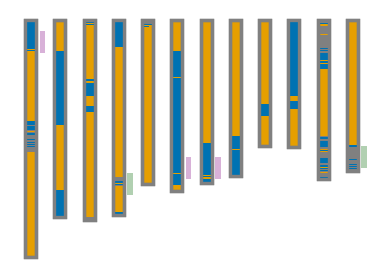

N08_011_S86.sort.bam


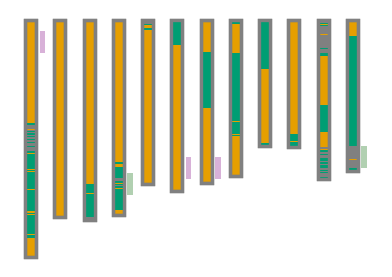

In [10]:
F3_colors = pd.Series(np.repeat("gray", Haplotype_block.shape[0]))
F3_colors[(Haplotype_block.N01_162 > 0) & (Haplotype_block.N08_011 == 0)] = "#0072B2"
F3_colors[(Haplotype_block.N01_162 == 0) & (Haplotype_block.N08_011 > 0)] = "#009E73"
F3_colors[(Haplotype_block.N01_162 > 0) & (Haplotype_block.N08_011 > 0)] = "gray"

for i in ["N01_162_S85.sort.bam", "N08_011_S86.sort.bam"]:
    print(i)
    tmp_genotype = final_F3_haplotype_blocks.loc[:, ["chr", "start", "end", i]]
    tmp_genotype["color"] = F3_colors
    visualize_F3_genotype(tmp_genotype, chr_ends, "#E69F00", N01_GN_top_regions, N08_PN_top_regions[:2], dpi=80, save=False, name=i[:i.find(".sort.bam")])

GP_B_01_S50.sort.bam


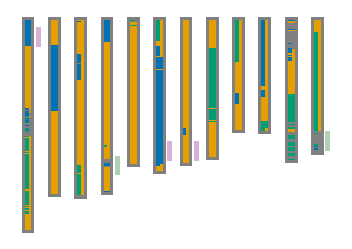

GP_B_02_S51.sort.bam


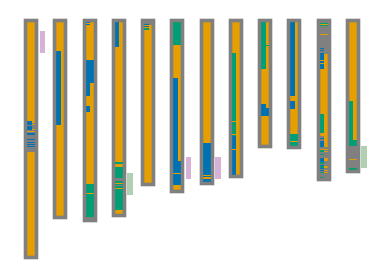

GP_B_03_S52.sort.bam


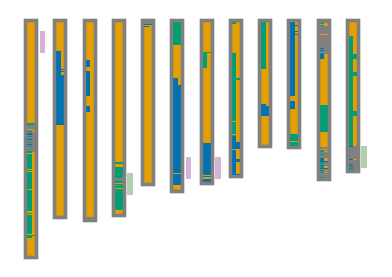

GP_B_04_S53.sort.bam


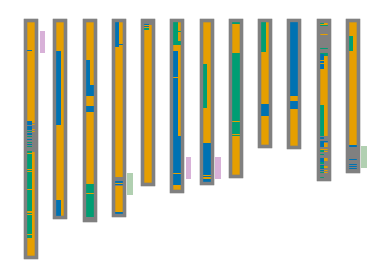

GP_B_05_S54.sort.bam


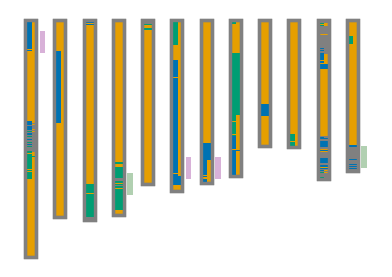

GP_B_06_S55.sort.bam


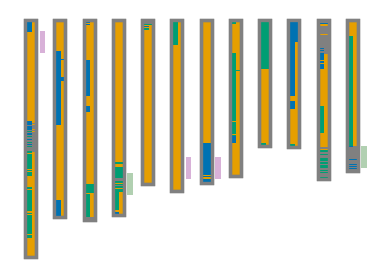

GP_B_07_S56.sort.bam


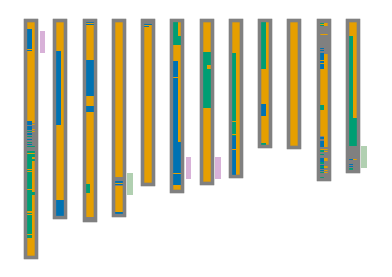

GP_B_08_S57.sort.bam


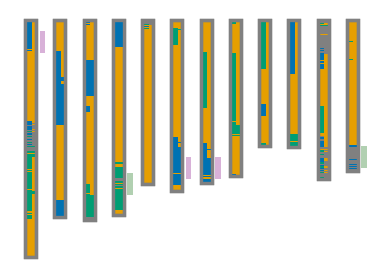

GP_B_09_S58.sort.bam


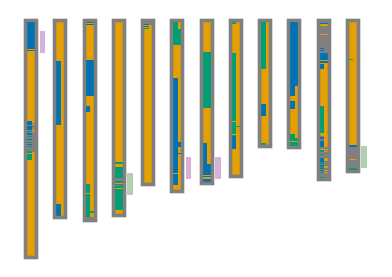

GP_B_10_S59.sort.bam


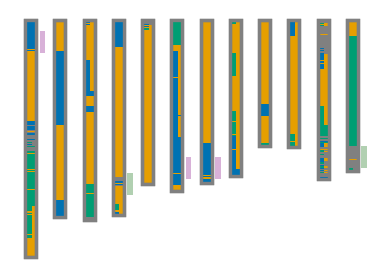

GP_B_11_S60.sort.bam


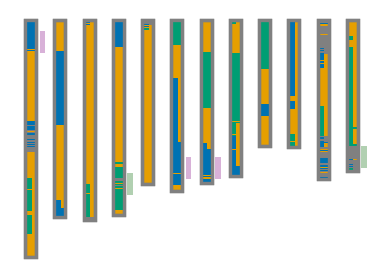

GP_B_12_S61.sort.bam


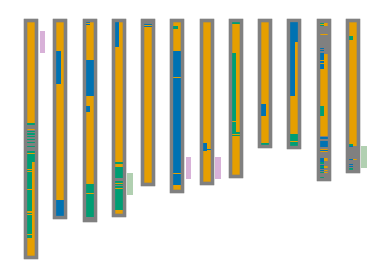

GP_B_13_S62.sort.bam


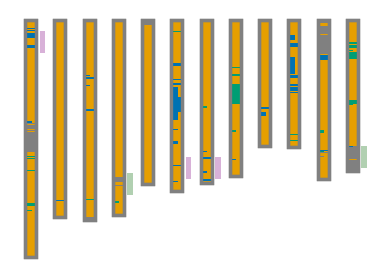

GP_B_14_S63.sort.bam


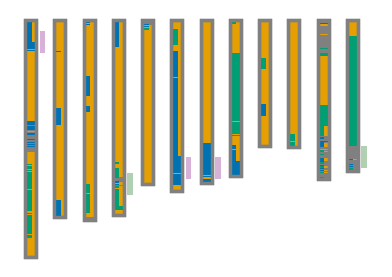

GP_B_15_S64.sort.bam


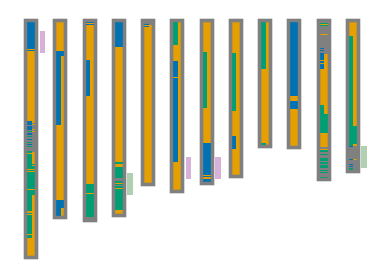

GP_B_16_S65.sort.bam


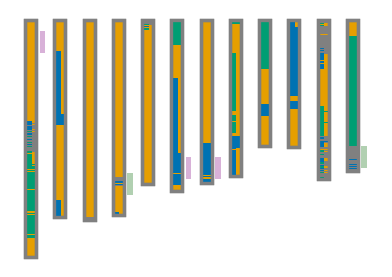

GP_B_17_S66.sort.bam


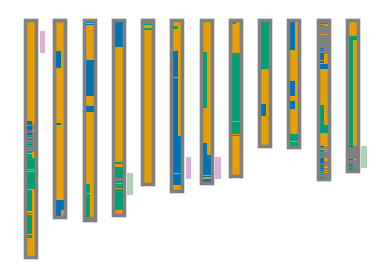

GP_B_18_S67.sort.bam


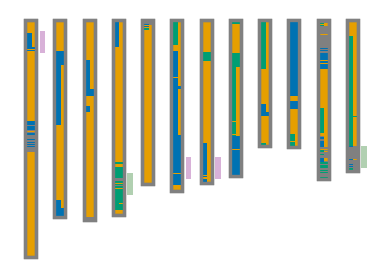

GP_B_19_S68.sort.bam


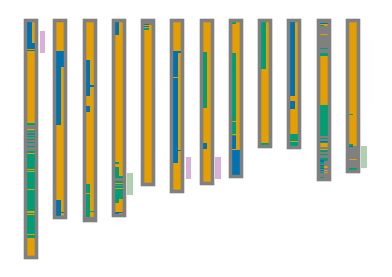

GP_B_20_S69.sort.bam


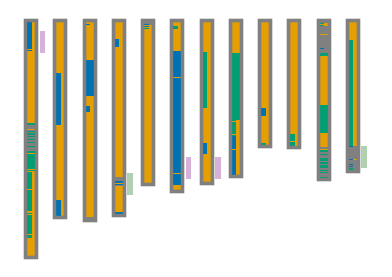

GP_B_21_S70.sort.bam


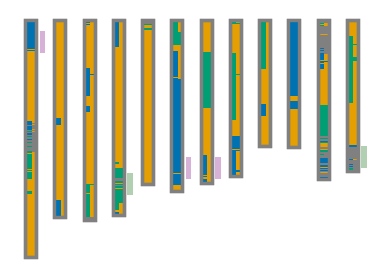

GP_B_22_S71.sort.bam


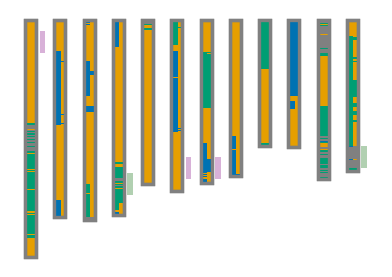

GP_B_23_S72.sort.bam


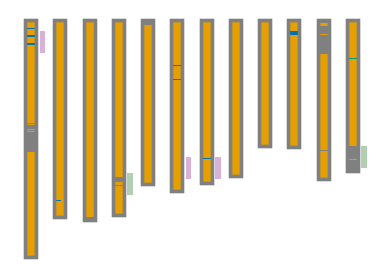

GP_B_24_S73.sort.bam


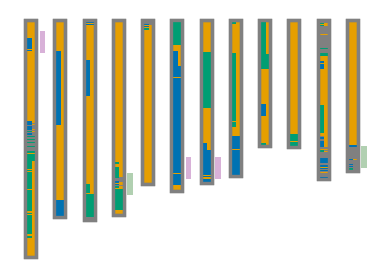

GP_B_25_S74.sort.bam


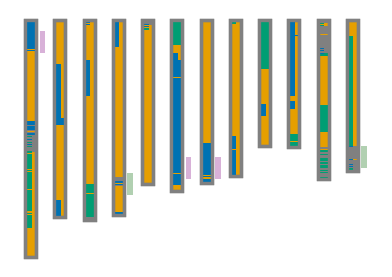

GP_B_26_S75.sort.bam


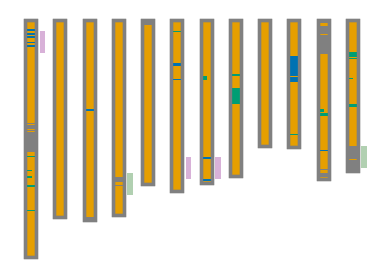

GP_B_27_S76.sort.bam


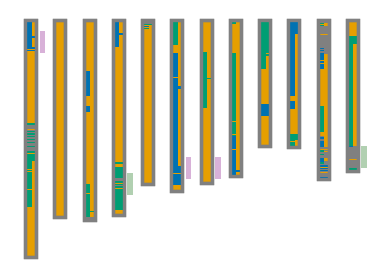

GP_B_28_S77.sort.bam


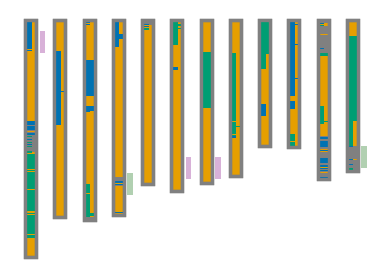

GP_B_29_S78.sort.bam


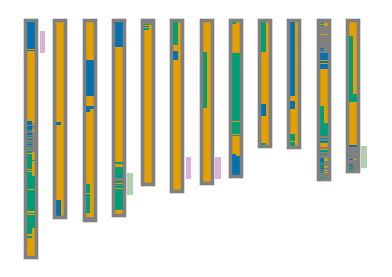

GP_B_30_S79.sort.bam


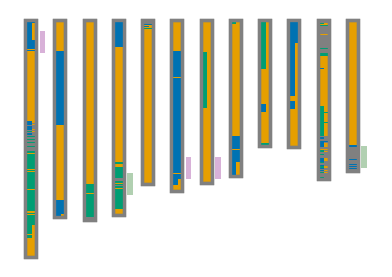

GP_B_31_S80.sort.bam


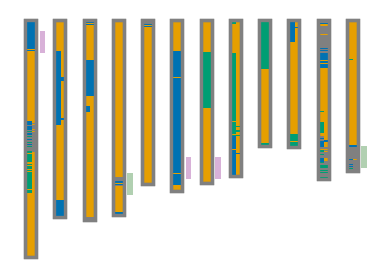

GP_B_32_S81.sort.bam


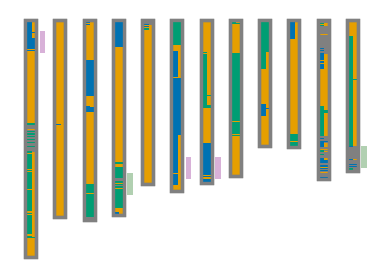

GP_B_33_S82.sort.bam


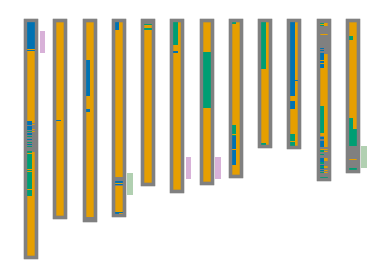

GP_B_34_S83.sort.bam


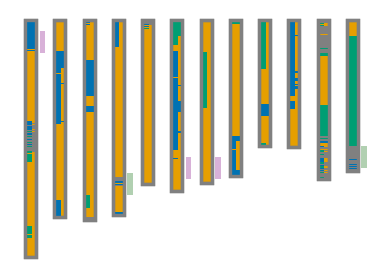

GP_B_35_S84.sort.bam


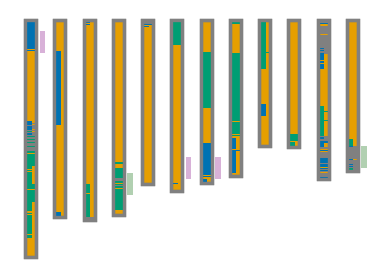

In [4]:
F3_colors = pd.Series(np.repeat("gray", Haplotype_block.shape[0]))
F3_colors[(Haplotype_block.N01_162 > 0) & (Haplotype_block.N08_011 == 0)] = "#0072B2"
F3_colors[(Haplotype_block.N01_162 == 0) & (Haplotype_block.N08_011 > 0)] = "#009E73"
F3_colors[(Haplotype_block.N01_162 > 0) & (Haplotype_block.N08_011 > 0)] = "gray"

for i in final_F3_haplotype_blocks.columns[final_F3_haplotype_blocks.columns.str.contains("GP_B")]:
    print(i)
    tmp_genotype = final_F3_haplotype_blocks.loc[:, ["chr", "start", "end", i]]
    tmp_genotype["color"] = F3_colors
    visualize_F3_genotype(tmp_genotype, chr_ends, "#E69F00", N01_GN_top_regions, N08_PN_top_regions[:2], dpi=80, save=False, name=i[:i.find(".sort.bam")])

GP_A_01_S23.sort.bam


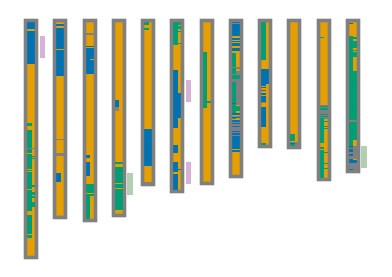

GP_A_02_S24.sort.bam


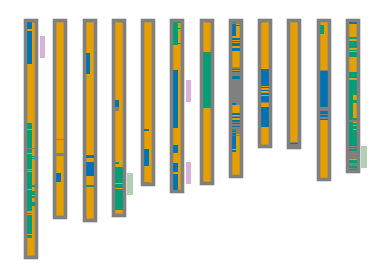

GP_A_03_S25.sort.bam


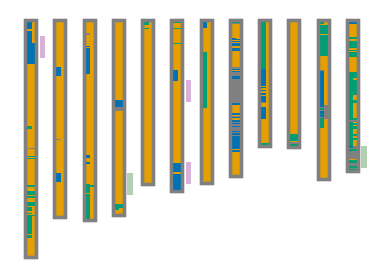

GP_A_04_S26.sort.bam


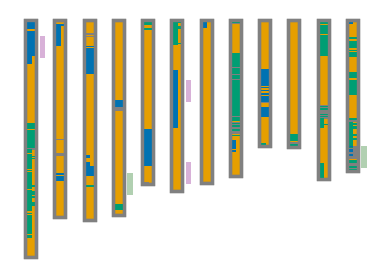

GP_A_05_S27.sort.bam


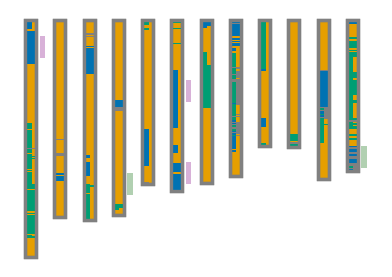

GP_A_06_S28.sort.bam


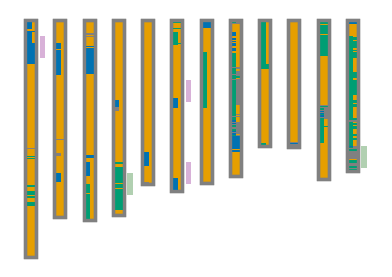

GP_A_08_S29.sort.bam


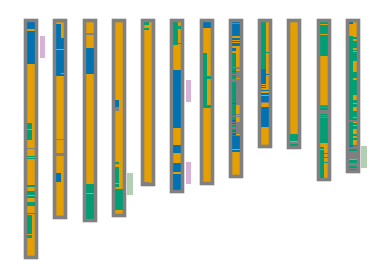

GP_A_09_S30.sort.bam


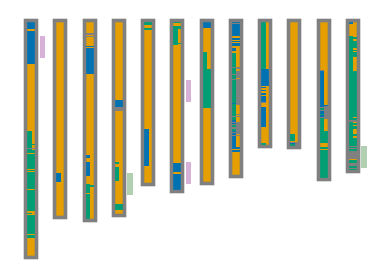

GP_A_10_S31.sort.bam


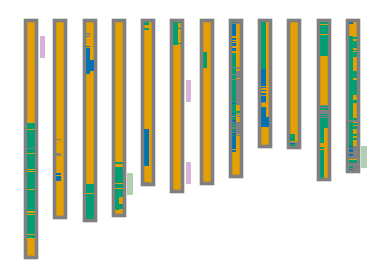

GP_A_13_S32.sort.bam


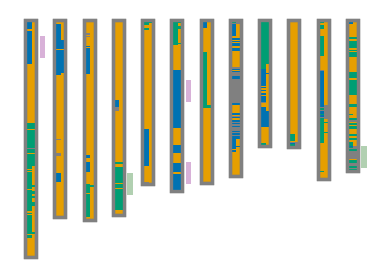

GP_A_16_S33.sort.bam


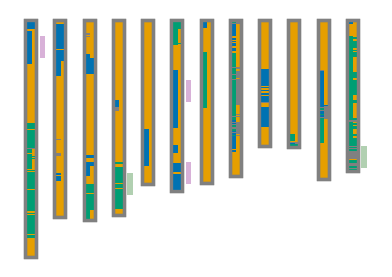

GP_A_19_S34.sort.bam


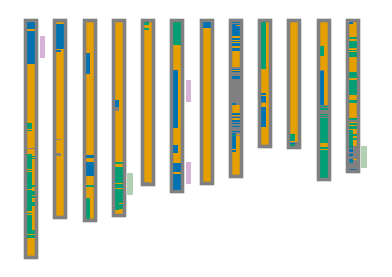

GP_A_24_S35.sort.bam


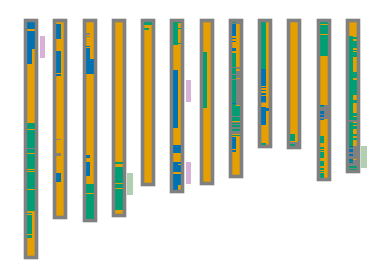

GP_A_28_S36.sort.bam


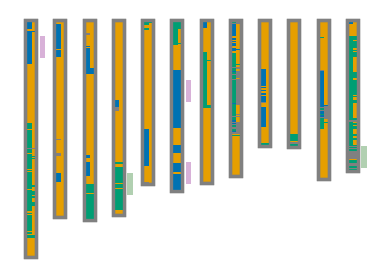

GP_A_29_S37.sort.bam


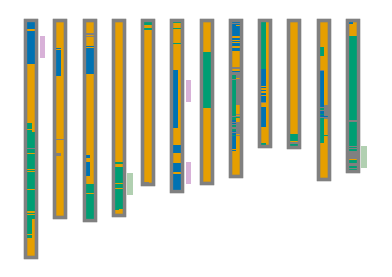

GP_A_32_S38.sort.bam


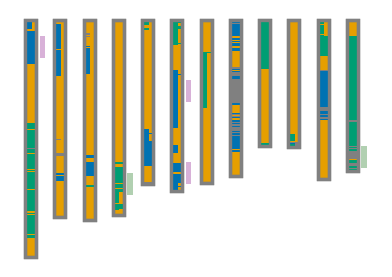

GP_A_33_S39.sort.bam


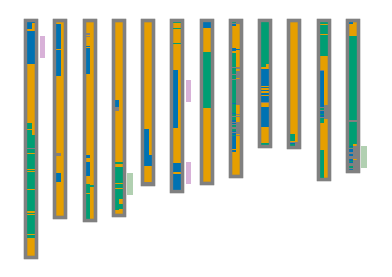

GP_A_34_S40.sort.bam


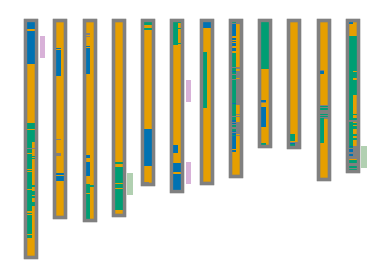

GP_A_35_S41.sort.bam


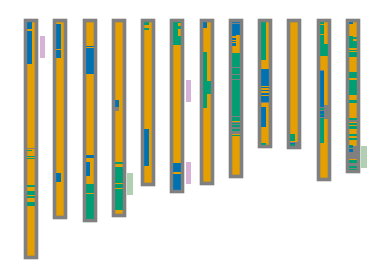

GP_A_46_S42.sort.bam


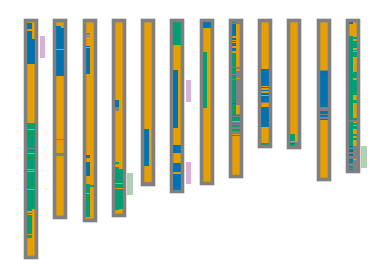

GP_A_48_S43.sort.bam


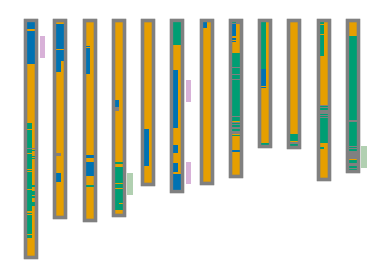

GP_A_49_S44.sort.bam


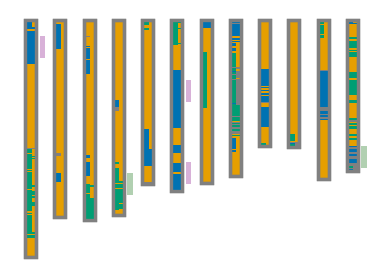

GP_A_53_S45.sort.bam


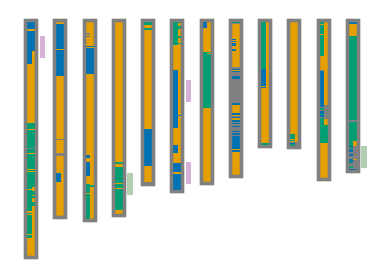

GP_A_54_S46.sort.bam


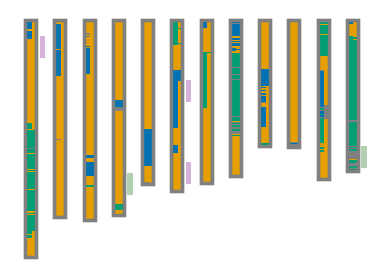

GP_A_55_S47.sort.bam


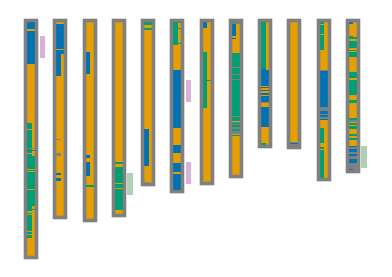

GP_A_56_S48.sort.bam


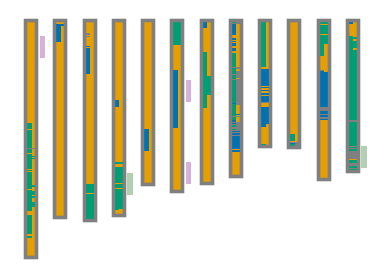

GP_A_57_S49.sort.bam


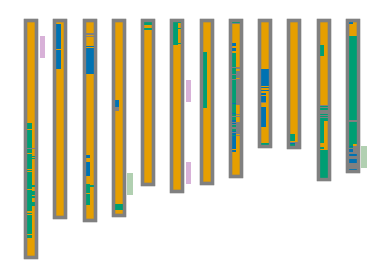

In [5]:
F3_colors = pd.Series(np.repeat("gray", Haplotype_block.shape[0]))
F3_colors[(Haplotype_block.N17_071 > 0) & (Haplotype_block.N08_011 == 0)] = "#0072B2"
F3_colors[(Haplotype_block.N17_071 == 0) & (Haplotype_block.N08_011 > 0)] = "#009E73"
F3_colors[(Haplotype_block.N17_071 > 0) & (Haplotype_block.N08_011 > 0)] = "gray"

for i in final_F3_haplotype_blocks.columns[final_F3_haplotype_blocks.columns.str.contains("GP_A")]:
    print(i)
    tmp_genotype = final_F3_haplotype_blocks.loc[:, ["chr", "start", "end", i]]
    tmp_genotype["color"] = F3_colors
    visualize_F3_genotype(tmp_genotype, chr_ends, "#E69F00", N17_GN_top_regions, N08_PN_top_regions[:2], dpi=80, save=False, name=i[:i.find(".sort.bam")])

In [45]:
imp_data = pd.read_csv("../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits_add.csv", dtype={'N01':str,'N03':str,'N04':str,'N05':str,'N06':str,'N07':str,'N08':str,'N09':str,'N10':str,'N11':str,'N12':str,'N13':str,'N14':str,'N16':str,'N17':str,'N18':str,'N19':str,'N20':str,'N21':str,'N22':str})
marker_for_pred = imp_data.loc[:, ["chr", "start", "end"]]
marker_for_pred["key"] = marker_for_pred["chr"] + "_" + marker_for_pred["start"].astype("str") + "_" + marker_for_pred["end"].astype("str")
final_F3_haplotype_blocks["key"] = final_F3_haplotype_blocks["chr"] + "_" + final_F3_haplotype_blocks["start"].astype("str") + "_" + final_F3_haplotype_blocks["end"].astype("str")
F3_genotype_for_preds = final_F3_haplotype_blocks.loc[final_F3_haplotype_blocks["key"].isin(marker_for_pred["key"])].iloc[:, 3:-3].T.fillna(0)
F3_genotype_for_preds

,13,14,77,83,122,187,194,222,223,238,...,56864,56925,56943,56966,56970,57020,57031,57037,57045,57057
N00_HITOMEBORE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
N01_162_S85.sort.bam,2.0,2.0,0.0,0.0,2.0,2.0,0.0,2.0,2.0,2.0,...,2.0,0.0,2.0,2.0,2.0,2.0,0.0,2.0,0.0,2.0
N01_KASALATH,2.0,2.0,0.0,0.0,2.0,2.0,0.0,2.0,2.0,2.0,...,2.0,0.0,2.0,2.0,2.0,2.0,0.0,2.0,0.0,2.0
N08_011_S86.sort.bam,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,2.0,2.0,2.0,2.0,0.0,2.0,0.0,2.0
N08_BADARI_DHAN,2.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,2.0,2.0,...,2.0,0.0,2.0,2.0,2.0,2.0,0.0,2.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GP_A_53_S45.sort.bam,0.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0,...,1.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
GP_A_54_S46.sort.bam,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,2.0,0.0,2.0,2.0,2.0,2.0,0.0,2.0,0.0,2.0
GP_A_55_S47.sort.bam,0.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,2.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0
GP_A_56_S48.sort.bam,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,2.0,2.0,2.0,2.0,0.0,2.0,0.0,2.0


In [46]:
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
k = 1
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV = 5
predicted_data = []
for trait_name in ["GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    print(trait_name)
    genotype_path = "../data/PART7_breeding_strategy/Haplotype_high_imp_HBs_for_3traits.csv" 
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype_path, phenotype, CV, seed=1024, plot=False, log=False)
    ideal_preds = []
    for i in range(CV):
        Enet_params = pd.read_csv("../data/PART7_breeding_strategy/Enet_high_imp_HBs_params.csv", index_col=0)
        Enet_params.columns = ["trait", "CV", "params"]
        Enet_params = ast.literal_eval(Enet_params.loc[(Enet_params["trait"] == trait_name) & (Enet_params["CV"] == i), "params"].values[0])
        tmp_train_data = train_data[i] 
        X_train = tmp_train_data[0].fillna(1)
        y_train = tmp_train_data[1]
        # train model
        clf = ElasticNet(alpha=Enet_params["alpha"], l1_ratio=Enet_params["l1_ratio"], max_iter=100000)
        clf.fit(X_train, y_train)
        # predicted values of test phenotype
        ideal_pred = clf.predict(F3_genotype_for_preds)
        ideal_preds.append(ideal_pred)
    ideal_preds = np.mean(ideal_preds, axis=0)
    predicted_data.append(ideal_preds)
predicted_data = pd.DataFrame(predicted_data)
predicted_data.index = ["GN_mean", "PN_mean", "Area.size.AS..mm2."]
predicted_data.columns = F3_genotype_for_preds.index.values
predicted_data

GN_mean
PN_mean
Area.size.AS..mm2.


,N00_HITOMEBORE,N01_162_S85.sort.bam,N01_KASALATH,N08_011_S86.sort.bam,N08_BADARI_DHAN,GP_B_01_S50.sort.bam,GP_B_02_S51.sort.bam,GP_B_03_S52.sort.bam,GP_B_04_S53.sort.bam,GP_B_05_S54.sort.bam,...,GP_A_34_S40.sort.bam,GP_A_35_S41.sort.bam,GP_A_46_S42.sort.bam,GP_A_48_S43.sort.bam,GP_A_49_S44.sort.bam,GP_A_53_S45.sort.bam,GP_A_54_S46.sort.bam,GP_A_55_S47.sort.bam,GP_A_56_S48.sort.bam,GP_A_57_S49.sort.bam
GN_mean,111.367888,211.947872,183.335558,90.346104,149.588323,149.310124,165.524839,145.122860,171.083313,152.210344,...,152.366452,140.624190,164.445761,147.083296,189.826395,152.541575,110.961279,180.702026,113.203945,93.246332
PN_mean,14.557327,13.418410,13.939950,19.206798,18.170721,16.416370,17.354197,17.234027,15.213561,17.074380,...,17.450945,17.009548,17.204602,16.115706,15.386161,17.089689,16.583164,16.354672,19.248419,15.225054
Area.size.AS..mm2.,17.142273,14.916842,14.798244,16.199126,17.185541,16.560436,13.804198,15.048506,15.101610,15.230219,...,17.653007,16.957961,16.777846,17.164391,16.887607,17.400588,17.298801,16.517912,15.878783,16.785396


In [55]:
N01N08_stats = pd.read_csv("../data/PARTEx_F3_genotype/N01N08_F3_region_rate.csv", index_col=0)
N01N08_stats = pd.concat([N01N08_stats, predicted_data.T.loc[N01N08_stats.index.values, :]], axis=1).to_csv("../data/PARTEx_F3_genotype/N01N08_F3_stats.csv")
N17N08_stats = pd.read_csv("../data/PARTEx_F3_genotype/N17N08_F3_region_rate.csv", index_col=0)
N17N08_stats = pd.concat([N17N08_stats, predicted_data.T.loc[N17N08_stats.index.values, :]], axis=1).to_csv("../data/PARTEx_F3_genotype/N17N08_F3_stats.csv")

In [112]:
F3_phenotypes = pd.read_excel("../data/PARTEx_F3_genotype/N17N08_F3_stats_with_phenotypes.xlsx")
available_lines = (F3_phenotypes.iloc[3:, 11:].isna().sum(axis=1) != 32).values
pred_phenotype = F3_phenotypes.iloc[3:, [6,7]].loc[available_lines, :]
pred_phenotype.index = F3_phenotypes.iloc[3:, 0].loc[available_lines]
raw_phenotype = F3_phenotypes.iloc[3:, 11:].loc[available_lines, :]
raw_phenotype.index = F3_phenotypes.iloc[3:, 0].loc[available_lines]
mean_phenotypes = []
for i in range(raw_phenotype.shape[0]):
    GN_PN = []
    for j in raw_phenotype.iloc[i, :].dropna().values:
        GN_PN.append([int(j.split(";")[1]), int(j.split(";")[0])])
    if len(GN_PN) > 200:
        a = pd.DataFrame(GN_PN).sort_values(by=0).index.values
        b = pd.DataFrame(GN_PN).sort_values(by=1).index.values
        GN_PN_drop = pd.DataFrame(GN_PN).drop(np.unique([a[0], a[-1], b[0], b[-1]]))
        mean_phenotypes.append([raw_phenotype.index.values[i], len(GN_PN), GN_PN_drop.shape[0], GN_PN_drop.iloc[:, 0].mean(), GN_PN_drop.iloc[:, 0].std(), GN_PN_drop.iloc[:, 1].mean(), GN_PN_drop.iloc[:, 1].std()])
    else:
        GN_PN_drop = pd.DataFrame(GN_PN)
        mean_phenotypes.append([raw_phenotype.index.values[i], len(GN_PN), len(GN_PN), GN_PN_drop.iloc[:, 0].mean(), GN_PN_drop.iloc[:, 0].std(), GN_PN_drop.iloc[:, 1].mean(), GN_PN_drop.iloc[:, 1].std()])
mean_phenotypes = pd.DataFrame(mean_phenotypes)
mean_phenotypes.columns = ["F3", "sample_num", "sample_used", "GN", "GN_std", "PN", "PN_std"]
mean_phenotypes["pred_PN"] = pred_phenotype.iloc[:, 1].values
mean_phenotypes["pred_GN"] = pred_phenotype.iloc[:, 0].values
mean_phenotypes.to_csv("../data/PARTEx_F3_genotype/N17N08_F3_mean_phenotypes.csv")
mean_phenotypes

,F3,sample_num,sample_used,GN,GN_std,PN,PN_std,pred_PN,pred_GN
0,GP_A_08_S29.sort.bam,32,32,174.375000,28.360297,18.031250,3.971547,17.265815,176.197423
1,GP_A_29_S37.sort.bam,16,16,131.875000,14.957161,16.062500,2.379601,16.767146,153.400254
2,GP_A_28_S36.sort.bam,16,16,129.250000,26.672083,17.625000,2.552776,17.367593,142.132736
3,GP_A_32_S38.sort.bam,16,16,137.687500,25.637781,15.625000,3.030402,16.464005,154.05897
4,GP_A_13_S32.sort.bam,16,16,127.062500,27.583736,19.625000,4.014557,17.842492,147.789713
5,GP_A_34_S40.sort.bam,9,9,135.111111,19.839635,18.555556,2.650996,17.450945,152.366452
6,GP_A_55_S47.sort.bam,1,1,216.000000,NaN,23.000000,NaN,16.354672,180.702026
7,GP_A_49_S44.sort.bam,4,4,168.500000,19.261360,21.500000,6.454972,15.386161,189.826395
8,GP_A_35_S41.sort.bam,12,12,138.000000,28.812876,19.333333,4.119429,17.009548,140.62419
9,GP_A_09_S30.sort.bam,7,7,142.142857,9.044862,16.714286,3.352327,15.826123,140.896714


,F3,sample_num,sample_used,GN,GN_std,PN,PN_std,pred_PN,pred_GN
0,GP_A_08_S29.sort.bam,32,32,174.375000,28.360297,18.031250,3.971547,17.265815,176.197422
1,GP_A_29_S37.sort.bam,16,16,131.875000,14.957161,16.062500,2.379601,16.767146,153.400254
2,GP_A_28_S36.sort.bam,16,16,129.250000,26.672083,17.625000,2.552776,17.367593,142.132736
3,GP_A_32_S38.sort.bam,16,16,137.687500,25.637781,15.625000,3.030402,16.464005,154.058970
4,GP_A_13_S32.sort.bam,16,16,127.062500,27.583736,19.625000,4.014557,17.842492,147.789713
5,GP_A_34_S40.sort.bam,9,9,135.111111,19.839635,18.555556,2.650996,17.450945,152.366452
8,GP_A_35_S41.sort.bam,12,12,138.000000,28.812876,19.333333,4.119429,17.009548,140.624190
9,GP_A_09_S30.sort.bam,7,7,142.142857,9.044862,16.714286,3.352327,15.826123,140.896714
10,GP_A_06_S28.sort.bam,10,10,122.900000,19.547378,20.500000,4.576510,17.555278,129.795819
14,GP_A_04_S26.sort.bam,16,16,167.750000,25.098473,15.875000,4.161330,14.546285,149.742627


0.7127257105584
0.8489056134490397


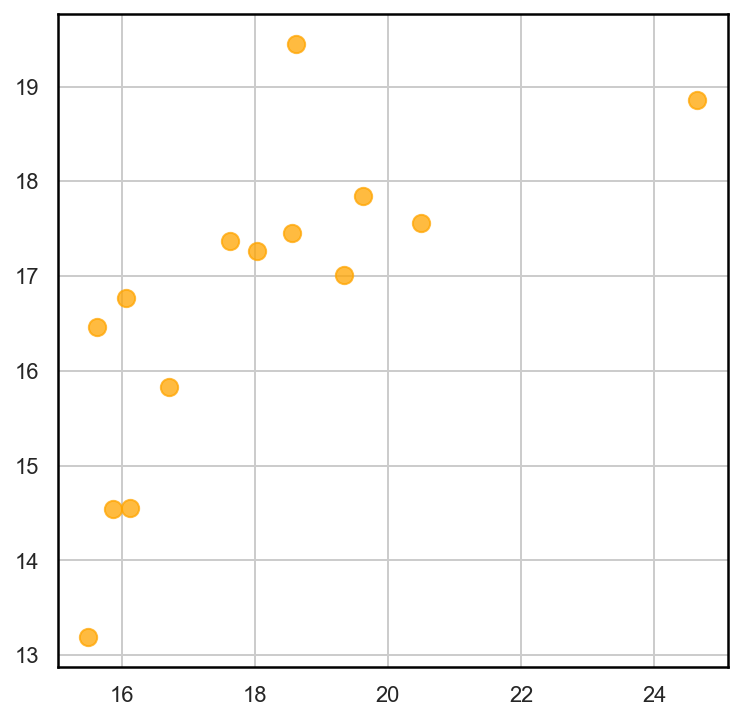

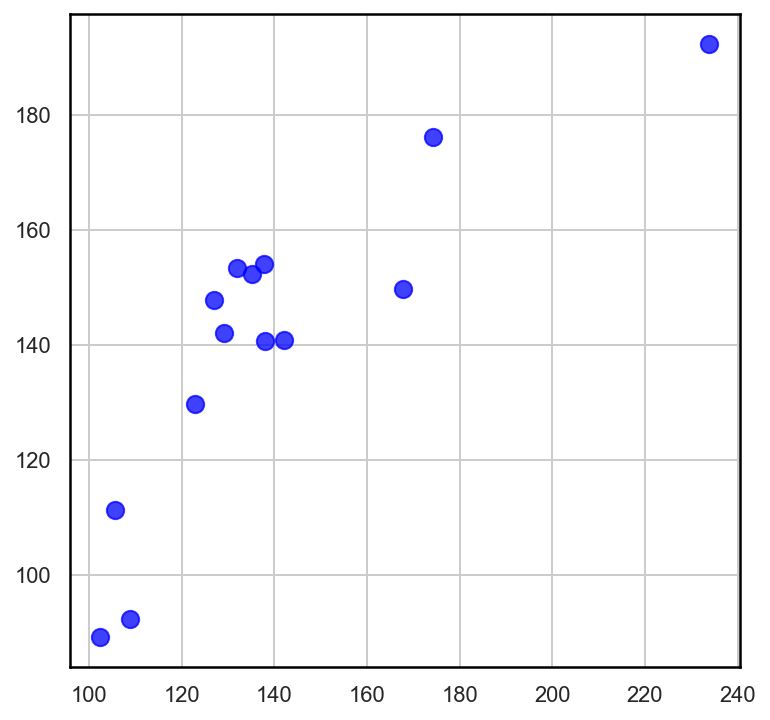

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}
sns.set()

mean_phenotypes = pd.read_csv("../data/PARTEx_F3_genotype/N17N08_F3_mean_phenotypes.csv", index_col=0)
tmp_mean_phenotypes = mean_phenotypes[mean_phenotypes.sample_num > 5]
tmp_mean_phenotypes = tmp_mean_phenotypes.drop([12])
display(tmp_mean_phenotypes)
print(np.corrcoef([tmp_mean_phenotypes["pred_PN"].values.astype("float"), tmp_mean_phenotypes["PN"].values.astype("float")])[0,1])
print(np.corrcoef([tmp_mean_phenotypes["pred_GN"].values.astype("float"), tmp_mean_phenotypes["GN"].values.astype("float")])[0,1])

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(data=tmp_mean_phenotypes, x="PN", y="pred_PN", s=75, color="orange", linewidth=1, alpha=0.75)
# min_val = min(min(Inov_obs), min(Inov_preds))
# max_val = max(max(Inov_obs), max(Inov_preds))
for sp in ["top", "left", "right", "bottom"]:
    ax.spines[sp].set_color('black')
plt.show()

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(data=tmp_mean_phenotypes, x="GN", y="pred_GN", s=75, color="blue", linewidth=1, alpha=0.75)
# min_val = min(min(Inov_obs), min(Inov_preds))
# max_val = max(max(Inov_obs), max(Inov_preds))
for sp in ["top", "left", "right", "bottom"]:
    ax.spines[sp].set_color('black')
plt.show()

In [43]:
tmp_mean_phenotypes["yield"] = tmp_mean_phenotypes["GN"]*tmp_mean_phenotypes["PN"]
colors = ["blue", "skyblue", "pink", "skyblue", "pink", "pink", "pink", "green", "red", "orange", "orange", "red", "red", "gray"]
tmp_mean_phenotypes


,F3,sample_num,sample_used,GN,GN_std,PN,PN_std,pred_PN,pred_GN,yield
0,GP_A_08_S29.sort.bam,32,32,174.375000,28.360297,18.031250,3.971547,17.265815,176.197422,3144.199219
1,GP_A_29_S37.sort.bam,16,16,131.875000,14.957161,16.062500,2.379601,16.767146,153.400254,2118.242188
2,GP_A_28_S36.sort.bam,16,16,129.250000,26.672083,17.625000,2.552776,17.367593,142.132736,2278.031250
3,GP_A_32_S38.sort.bam,16,16,137.687500,25.637781,15.625000,3.030402,16.464005,154.058970,2151.367188
4,GP_A_13_S32.sort.bam,16,16,127.062500,27.583736,19.625000,4.014557,17.842492,147.789713,2493.601562
5,GP_A_34_S40.sort.bam,9,9,135.111111,19.839635,18.555556,2.650996,17.450945,152.366452,2507.061729
8,GP_A_35_S41.sort.bam,12,12,138.000000,28.812876,19.333333,4.119429,17.009548,140.624190,2668.000000
9,GP_A_09_S30.sort.bam,7,7,142.142857,9.044862,16.714286,3.352327,15.826123,140.896714,2375.816325
10,GP_A_06_S28.sort.bam,10,10,122.900000,19.547378,20.500000,4.576510,17.555278,129.795819,2519.450000
14,GP_A_04_S26.sort.bam,16,16,167.750000,25.098473,15.875000,4.161330,14.546285,149.742627,2663.031250


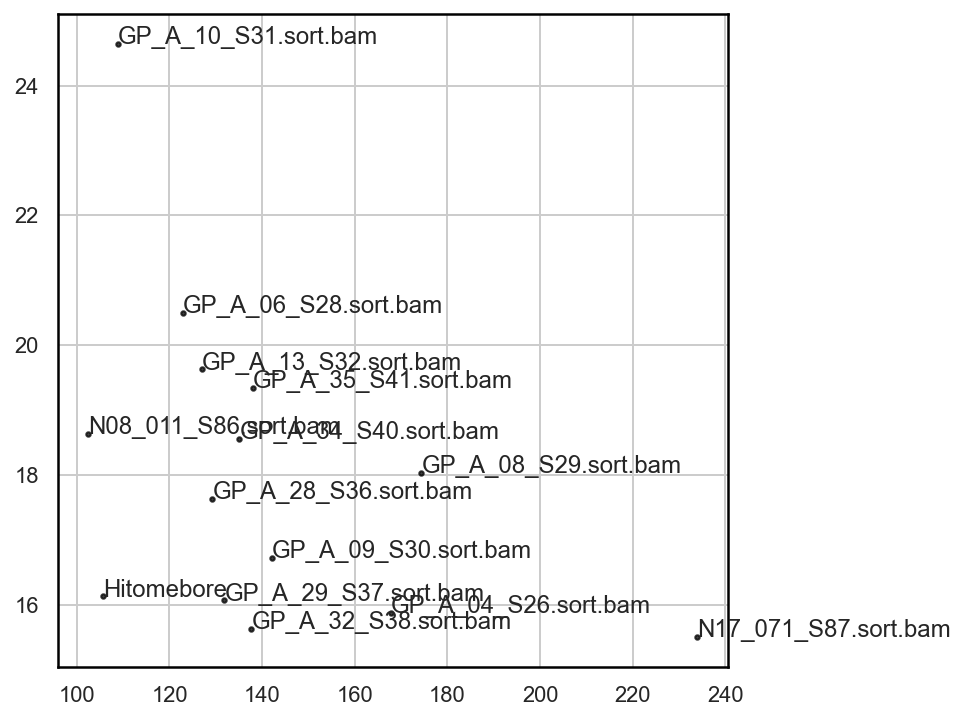

In [46]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6,6))
# sc = ax.scatter(data=tmp_mean_phenotypes, x="GN", y="PN", s=75, c=tmp_mean_phenotypes["GN"]*tmp_mean_phenotypes["PN"], linewidth=1, alpha=0.75, cmap="Reds")
sc = ax.scatter(data=tmp_mean_phenotypes, x="GN", y="PN", s=5, c="black", linewidth=1, alpha=0.75)
# sc = ax.scatter(data=tmp_mean_phenotypes, x="GN", y="PN", s=400, c=colors, marker="*", linewidth=1, alpha=0.75)
# sc = ax.scatter(data=tmp_mean_phenotypes, x="GN", y="PN", s=400, marker="*", facecolors='none', edgecolors='r', linewidth=1, alpha=0.75)
# plt.colorbar(sc)
# min_val = min(min(Inov_obs), min(Inov_preds))
# max_val = max(max(Inov_obs), max(Inov_preds))

for i, txt in enumerate(tmp_mean_phenotypes.F3.values):
    ax.annotate(txt, (tmp_mean_phenotypes.GN.values[i], tmp_mean_phenotypes.PN.values[i]))
    
for sp in ["top", "left", "right", "bottom"]:
    ax.spines[sp].set_color('black')
    
plt.show()

In [11]:
F3_N17N08_genotype = pd.read_csv("../data/PARTEx_F3_genotype/vcf/F3_N17N08_SNP_with_parents_genotype.txt", sep="\t")
F3_N17N08_genotype

,Marker,chr,pos,N00_HITOMEBORE,N08_011_S86.sort.bam,N08_BADARI_DHAN,N17_071_S87.sort.bam,N17_TAKANARI,GP_A_01_S23.sort.bam,GP_A_02_S24.sort.bam,...,GP_A_34_S40.sort.bam,GP_A_35_S41.sort.bam,GP_A_46_S42.sort.bam,GP_A_48_S43.sort.bam,GP_A_49_S44.sort.bam,GP_A_53_S45.sort.bam,GP_A_54_S46.sort.bam,GP_A_55_S47.sort.bam,GP_A_56_S48.sort.bam,GP_A_57_S49.sort.bam
0,1,chr01,173888,0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,chr01,173890,0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,chr01,173911,0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,chr01,173923,0,0.0,0.0,2.0,2.0,NaN,1.0,...,2.0,1.0,0.0,2.0,1.0,2.0,1.0,2.0,0.0,0.0
4,5,chr01,173989,0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825387,825388,chr12,27530133,0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0
825388,825389,chr12,27530457,0,2.0,2.0,2.0,2.0,NaN,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
825389,825390,chr12,27530477,0,2.0,2.0,2.0,2.0,NaN,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
825390,825391,chr12,27530489,0,2.0,2.0,2.0,2.0,NaN,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
